In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys
from sklearn.metrics import confusion_matrix
import seaborn as sns
from collections import Counter


from sklearn.model_selection import train_test_split
sys.path.append('../../Share/')
import Model

def random_downsample_Num(X, y=None, n_keep=None, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    if n_keep is None or n_keep > n_samples:
        raise ValueError(f"n_keep must be between 1 and {n_samples}, got {n_keep}")

    idx_keep = np.random.choice(n_samples, size=n_keep, replace=False)
    X_down = X[idx_keep]

    if y is not None:
        y_down = y[idx_keep]
        return X_down, y_down
    else:
        return X_down


def filtering_zero(X, y, erase_label):
    # 1. erase_label 제거
    keep_indices = y != erase_label
    X = X[keep_indices]
    y = y[keep_indices]

    # 2. erase_label보다 큰 값은 1씩 감소
    y = np.where(y > erase_label, y - 1, y)

    return X, y


def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    return cm

def vis_graph(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.legend()
    plt.show()

def train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False):
    #X_train, y_train = filtering_zero(X_train, y_train, erase_label=0)
    #X_test, y_test = filtering_zero(X_test, y_test, erase_label=0)

    model = Model.Original_model(X_train.shape[1:], num_class=np.max(y_train)+1)

    history, model = Model.Train_model(
        model, X_train, y_train, X_test, y_test,
        set_epoch=100, set_batch_size=256, Model_name='V0',
        set_verbose=False, save_model_set=False
    )
    if draw_learning_curve:
        vis_graph(history)

    if heatmap_bool:
        CM = heatmap_confusion_matrix(X_test, y_test, model)
        return CM

    return None

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

def get_X_y(X_lst, y_lst, session, balance=True):
    X, y = [], []
    for t in session:
        X_tmp, y_tmp = X_lst[t].reshape(-1,16,14,1), y_lst[t]
        X.append(X_tmp)
        y.append(y_tmp)

    X, y = np.concatenate(X, axis=0), np.concatenate(y, axis=0)
    if balance:
        X,y = balance_data(X, y)
    return X, y

In [5]:
# subject 1 - dont use

path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
fname = os.listdir(path)

subjects = {
    "subject1": {"X": [], "Y": []},
    "subject2": {"X": [], "Y": []},
    "subject3": {"X": [], "Y": []},
}

for f in fname:
    for i in range(10):
        X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
        y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))

        # shuffle
        #indices = np.random.permutation(len(X))
        #X, y = X[indices], y[indices]

        # convert one-hot to integer labels
        y_int = np.argmax(y, axis=1)
        num_classes = np.max(y_int) + 1

        # example rule to assign data to subject dict
        if "subject1" in f:
            subjects["subject1"]["X"].append(X)
            subjects["subject1"]["Y"].append(y_int)
        elif "subject2" in f:
            subjects["subject2"]["X"].append(X)
            subjects["subject2"]["Y"].append(y_int)
        elif "subject3" in f:
            subjects["subject3"]["X"].append(X)
            subjects["subject3"]["Y"].append(y_int)

3 0
(54138, 16, 14, 1) (54138,) (9246, 16, 14, 1) (9246,)
Start Training (total epochs: 100)...
Maximum training accuracy : 65.21%
Maximum validation accuracy : 57.38%


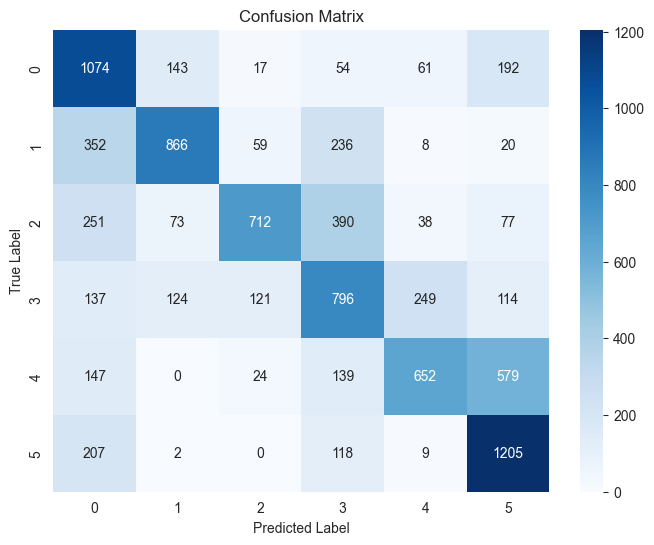

6 2
(52710, 16, 14, 1) (52710,) (13380, 16, 14, 1) (13380,)
Start Training (total epochs: 100)...
Maximum training accuracy : 62.69%
Maximum validation accuracy : 63.1%


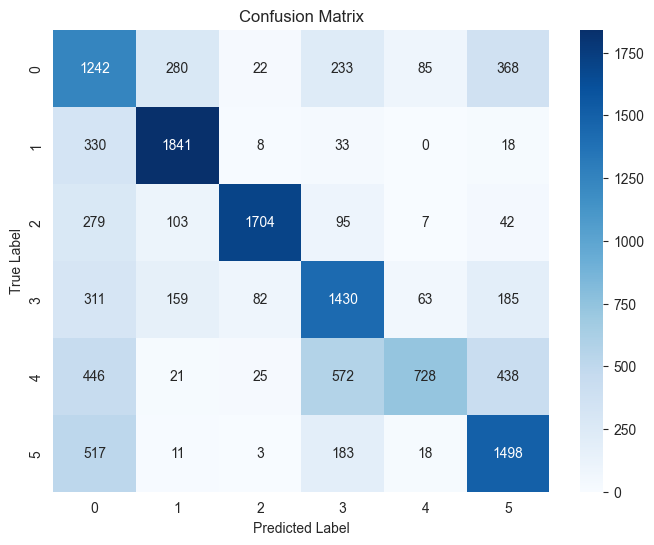

5 6
(52482, 16, 14, 1) (52482,) (13494, 16, 14, 1) (13494,)
Start Training (total epochs: 100)...
Maximum training accuracy : 64.9%
Maximum validation accuracy : 45.12%


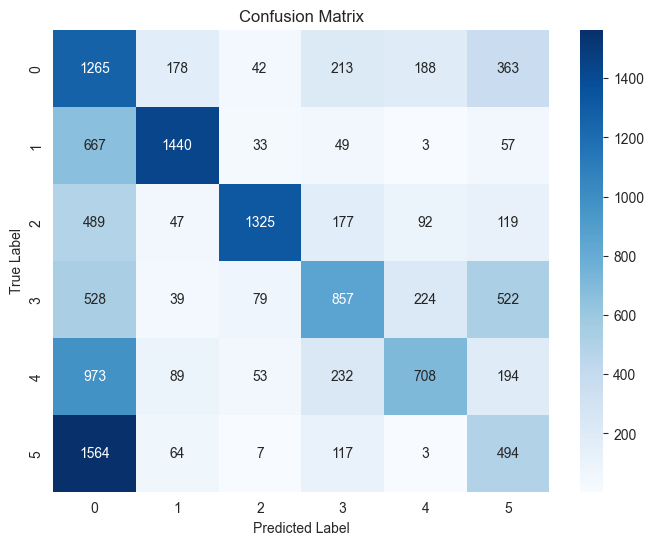

6 3
(53250, 16, 14, 1) (53250,) (10374, 16, 14, 1) (10374,)
Start Training (total epochs: 100)...
Maximum training accuracy : 62.22%
Maximum validation accuracy : 61.2%


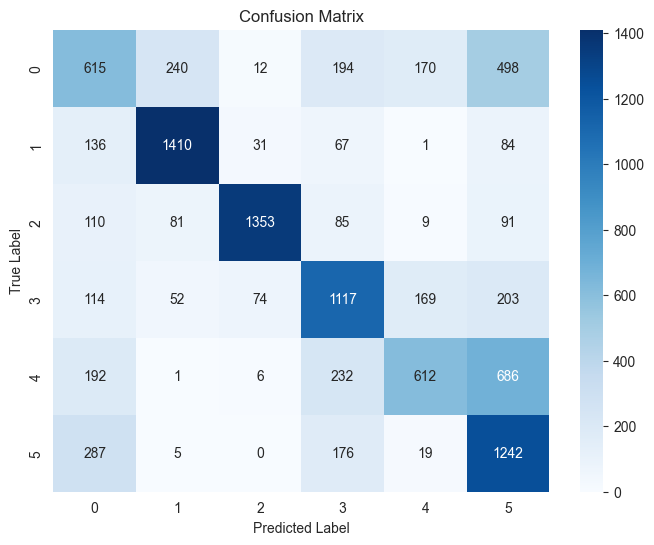

9 2
(51414, 16, 14, 1) (51414,) (12804, 16, 14, 1) (12804,)
Start Training (total epochs: 100)...
Maximum training accuracy : 65.38%
Maximum validation accuracy : 55.13%


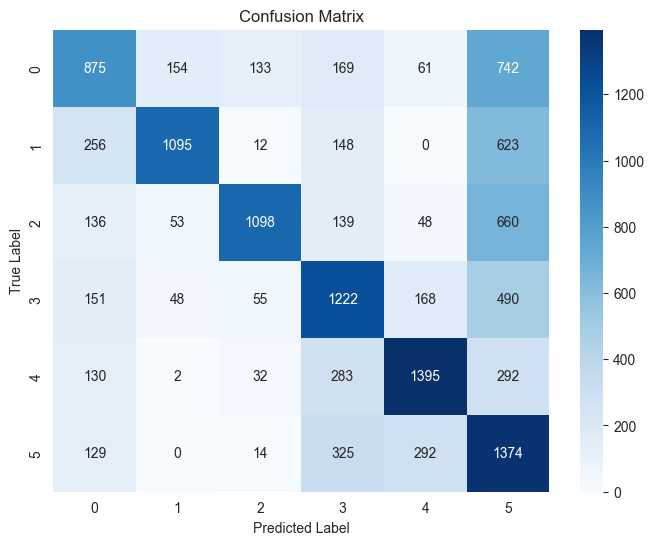

In [6]:
X_lst2, y_lst2 = subjects["subject2"]["X"], subjects["subject2"]["Y"]
import random
CM_lst_S2 = []

for repeat in range(5):
    numbers = list(range(10))
    a, b = random.sample(numbers, 2)
    numbers.remove(a)
    numbers.remove(b)
    print(a,b)

    X_train, y_train = get_X_y(X_lst2, y_lst2, session=numbers, balance=True)
    X_test, y_test = get_X_y(X_lst2, y_lst2, session=[a,b], balance=True) #2개씩 해야함 - 10tirals *2 = 20 = same with the sENG setting

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    CM_s2 = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    CM_lst_S2.append(CM_s2)

In [7]:
CM_lst_S2

[array([[1074,  143,   17,   54,   61,  192],
        [ 352,  866,   59,  236,    8,   20],
        [ 251,   73,  712,  390,   38,   77],
        [ 137,  124,  121,  796,  249,  114],
        [ 147,    0,   24,  139,  652,  579],
        [ 207,    2,    0,  118,    9, 1205]]),
 array([[1242,  280,   22,  233,   85,  368],
        [ 330, 1841,    8,   33,    0,   18],
        [ 279,  103, 1704,   95,    7,   42],
        [ 311,  159,   82, 1430,   63,  185],
        [ 446,   21,   25,  572,  728,  438],
        [ 517,   11,    3,  183,   18, 1498]]),
 array([[1265,  178,   42,  213,  188,  363],
        [ 667, 1440,   33,   49,    3,   57],
        [ 489,   47, 1325,  177,   92,  119],
        [ 528,   39,   79,  857,  224,  522],
        [ 973,   89,   53,  232,  708,  194],
        [1564,   64,    7,  117,    3,  494]]),
 array([[ 615,  240,   12,  194,  170,  498],
        [ 136, 1410,   31,   67,    1,   84],
        [ 110,   81, 1353,   85,    9,   91],
        [ 114,   52,   74, 1

7 8
(52092, 16, 14, 1) (52092,) (13998, 16, 14, 1) (13998,)
Start Training (total epochs: 100)...
Maximum training accuracy : 73.31%
Maximum validation accuracy : 47.48%


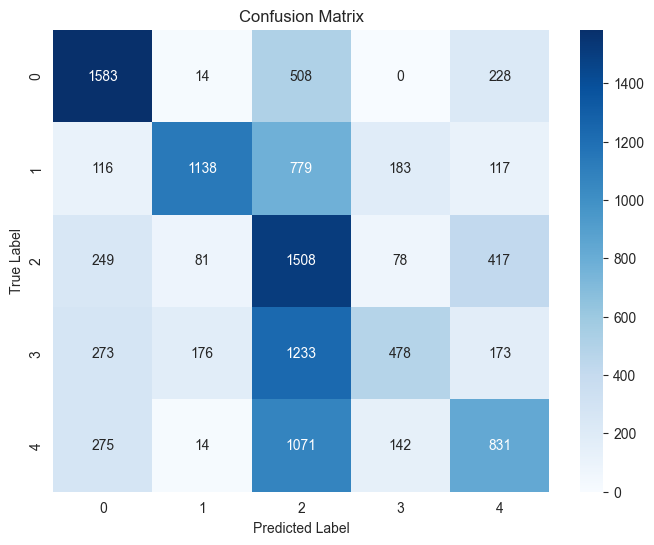

9 6
(52710, 16, 14, 1) (52710,) (13380, 16, 14, 1) (13380,)
Start Training (total epochs: 100)...
Maximum training accuracy : 72.78%
Maximum validation accuracy : 54.66%


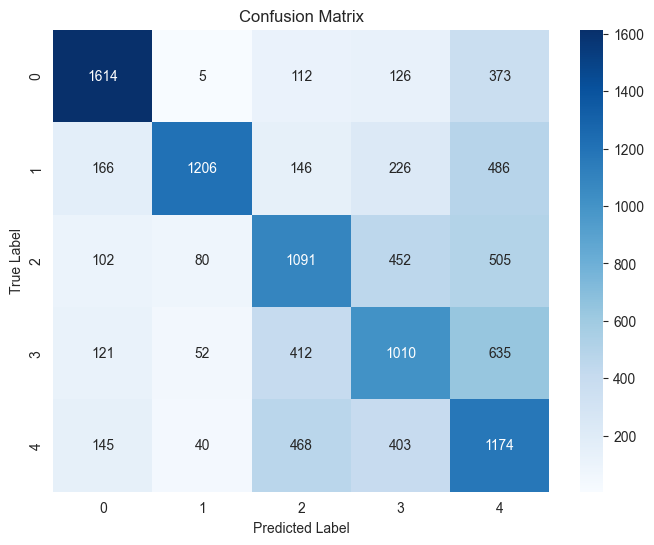

0 8
(53526, 16, 14, 1) (53526,) (12036, 16, 14, 1) (12036,)
Start Training (total epochs: 100)...
Maximum training accuracy : 73.49%
Maximum validation accuracy : 49.79%


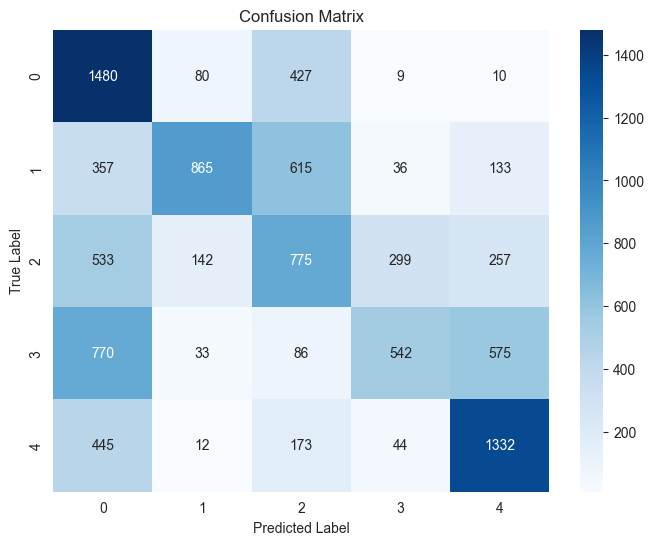

8 4
(51444, 16, 14, 1) (51444,) (13332, 16, 14, 1) (13332,)
Start Training (total epochs: 100)...
Maximum training accuracy : 71.66%
Maximum validation accuracy : 49.86%


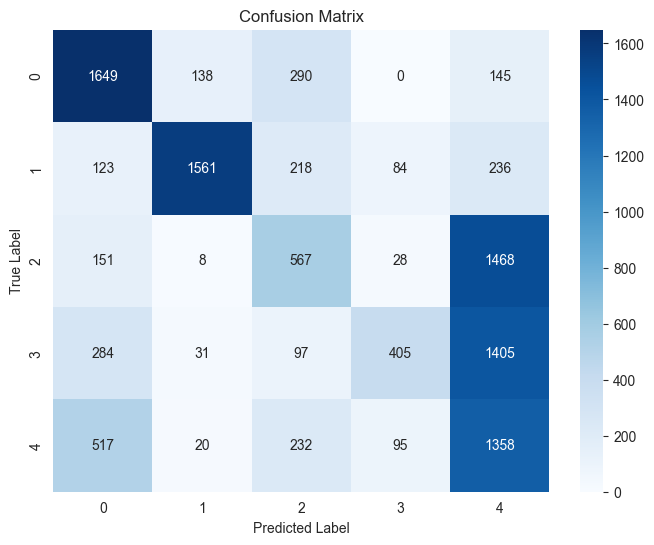

2 8
(51630, 16, 14, 1) (51630,) (13338, 16, 14, 1) (13338,)
Start Training (total epochs: 100)...
Maximum training accuracy : 69.25%
Maximum validation accuracy : 68.8%


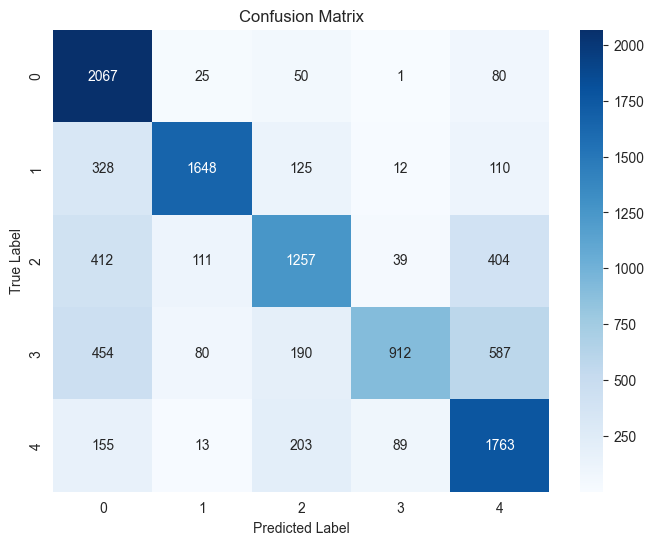

In [17]:
X_lst2, y_lst2 = subjects["subject2"]["X"], subjects["subject2"]["Y"]
import random
CM_lst_S2 = []

for repeat in range(5):
    numbers = list(range(10))
    a, b = random.sample(numbers, 2)
    numbers.remove(a)
    numbers.remove(b)
    print(a,b)

    X_train, y_train = get_X_y(X_lst2, y_lst2, session=numbers, balance=True)
    X_test, y_test = get_X_y(X_lst2, y_lst2, session=[a,b], balance=True) #2개씩 해야함 - 10tirals *2 = 20 = same with the sENG setting

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    CM_s2 = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    CM_lst_S2.append(CM_s2)

9 7
(62424, 16, 14, 1) (62424,) (14868, 16, 14, 1) (14868,)
Start Training (total epochs: 100)...
Maximum training accuracy : 68.62%
Maximum validation accuracy : 52.55%


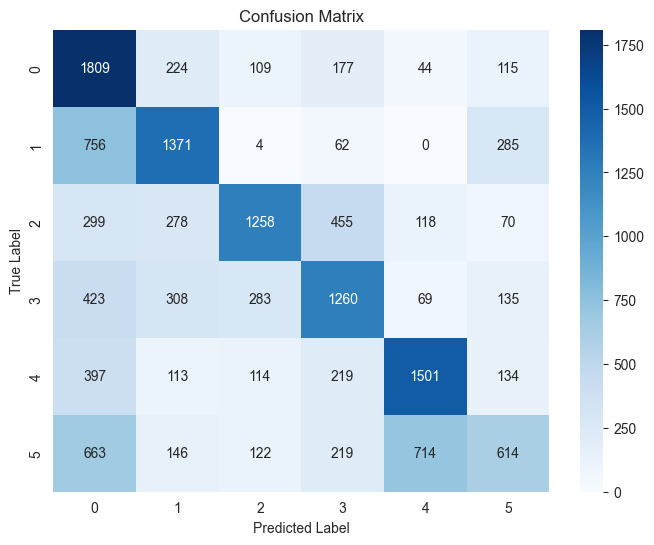

1 9
(62286, 16, 14, 1) (62286,) (15252, 16, 14, 1) (15252,)
Start Training (total epochs: 100)...
Maximum training accuracy : 69.41%
Maximum validation accuracy : 45.41%


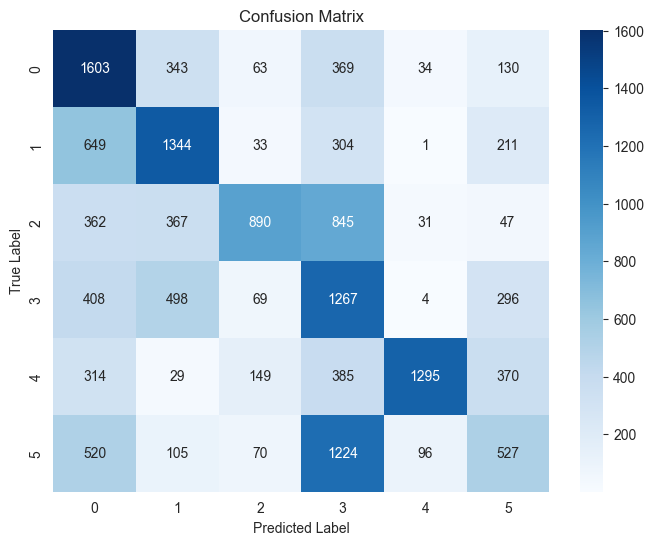

9 6
(61794, 16, 14, 1) (61794,) (14874, 16, 14, 1) (14874,)
Start Training (total epochs: 100)...
Maximum training accuracy : 68.57%
Maximum validation accuracy : 56.39%


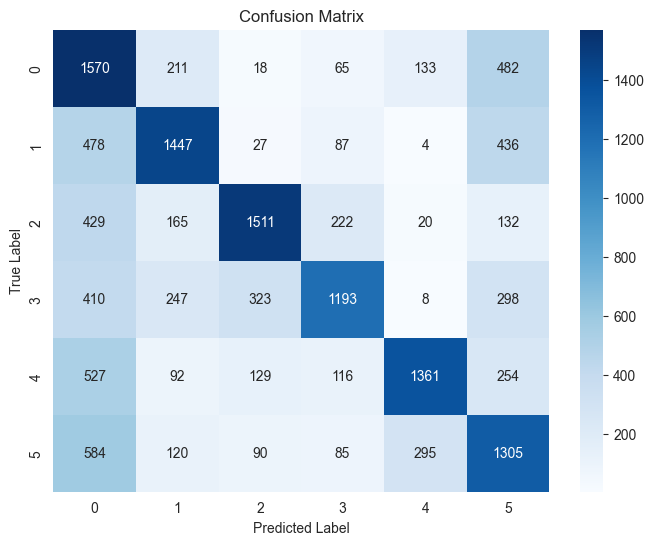

0 7
(62016, 16, 14, 1) (62016,) (15648, 16, 14, 1) (15648,)
Start Training (total epochs: 100)...
Maximum training accuracy : 67.16%
Maximum validation accuracy : 46.03%


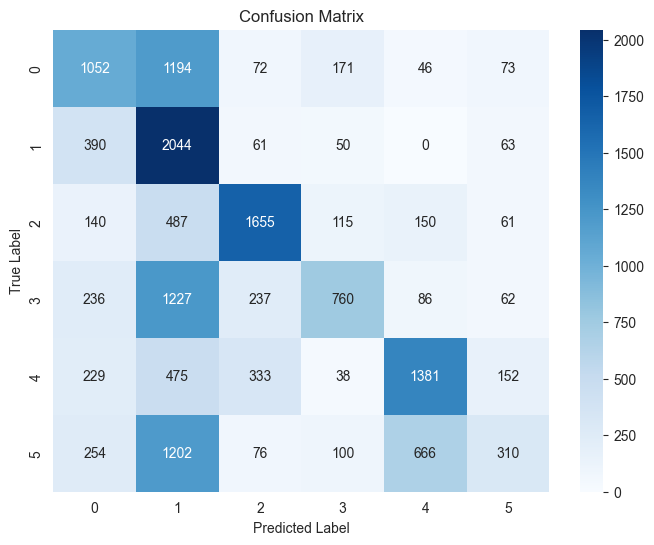

5 6
(62088, 16, 14, 1) (62088,) (15516, 16, 14, 1) (15516,)
Start Training (total epochs: 100)...
Maximum training accuracy : 67.14%
Maximum validation accuracy : 60.05%


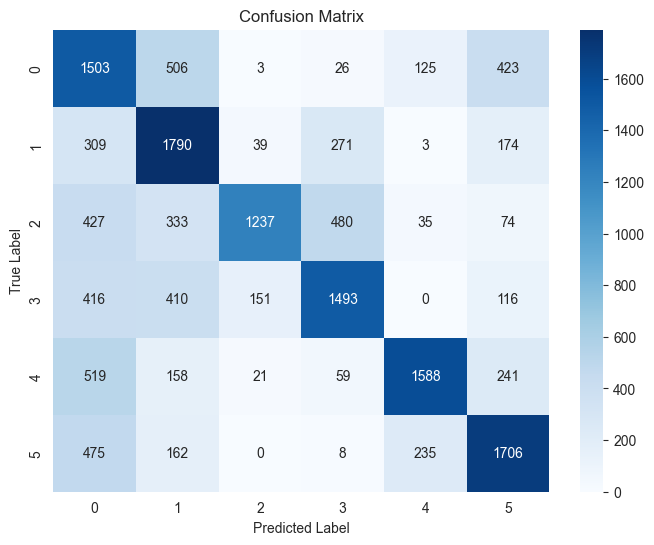

In [8]:
X_lst3, y_lst3 = subjects["subject3"]["X"], subjects["subject3"]["Y"]
import random
CM_lst_S3 = []

for repeat in range(5):
    numbers = list(range(10))
    a, b = random.sample(numbers, 2)
    numbers.remove(a)
    numbers.remove(b)
    print(a,b)

    X_train, y_train = get_X_y(X_lst3, y_lst3, session=numbers, balance=True)
    X_test, y_test = get_X_y(X_lst3, y_lst3, session=[a,b], balance=True) #2개씩 해야함 - 10tirals *2 = 20 = same with the sENG setting

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    CM_s3 = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    CM_lst_S3.append(CM_s3)

1 6
(61986, 16, 14, 1) (61986,) (15702, 16, 14, 1) (15702,)
Start Training (total epochs: 100)...
Maximum training accuracy : 75.03%
Maximum validation accuracy : 54.25%


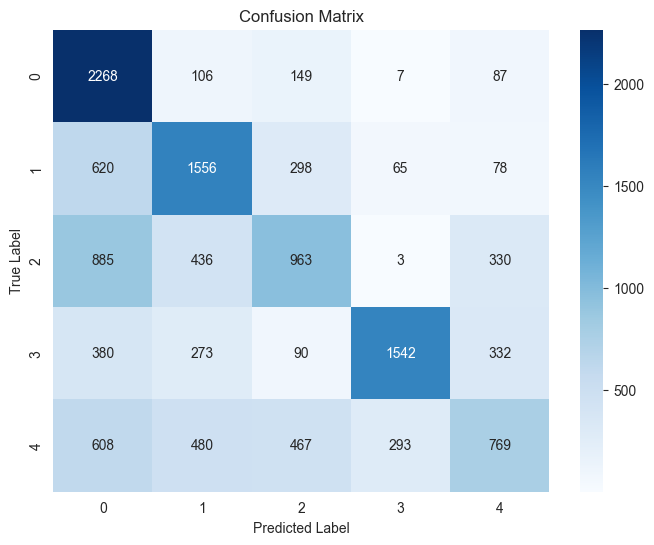

9 4
(62082, 16, 14, 1) (62082,) (15534, 16, 14, 1) (15534,)
Start Training (total epochs: 100)...
Maximum training accuracy : 78.12%
Maximum validation accuracy : 45.25%


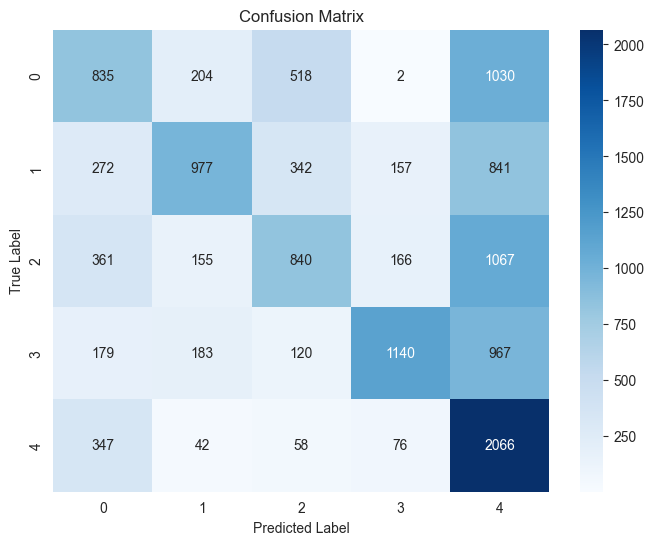

3 8
(62478, 16, 14, 1) (62478,) (15204, 16, 14, 1) (15204,)
Start Training (total epochs: 100)...
Maximum training accuracy : 70.75%
Maximum validation accuracy : 50.91%


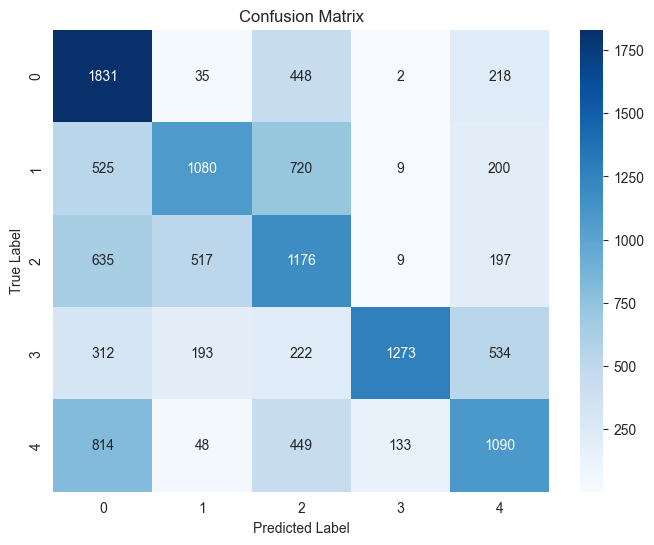

7 0
(62016, 16, 14, 1) (62016,) (15648, 16, 14, 1) (15648,)
Start Training (total epochs: 100)...
Maximum training accuracy : 74.22%
Maximum validation accuracy : 49.21%


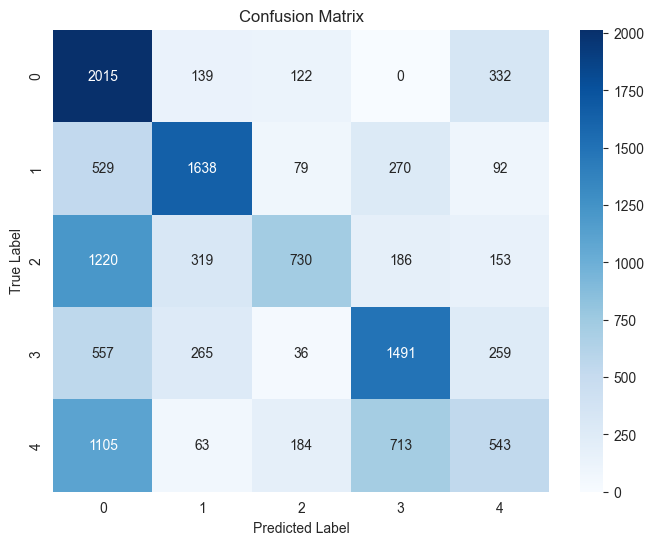

6 5
(62088, 16, 14, 1) (62088,) (15516, 16, 14, 1) (15516,)
Start Training (total epochs: 100)...
Maximum training accuracy : 77.24%
Maximum validation accuracy : 64.39%


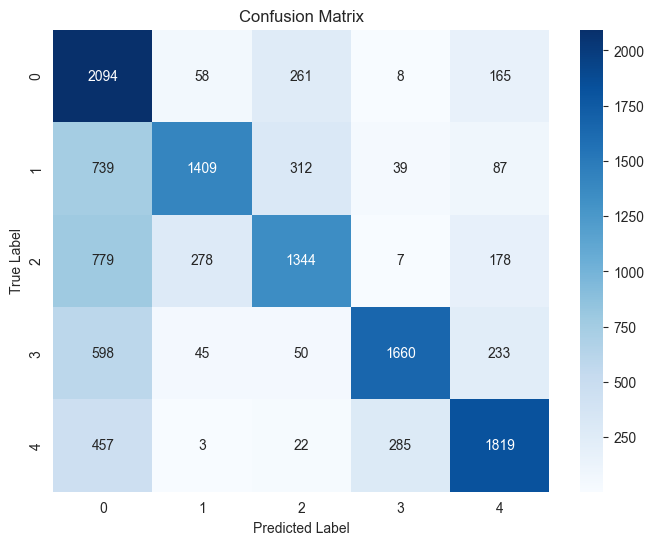

In [18]:
X_lst3, y_lst3 = subjects["subject3"]["X"], subjects["subject3"]["Y"]
import random
CM_lst_S3 = []

for repeat in range(5):
    numbers = list(range(10))
    a, b = random.sample(numbers, 2)
    numbers.remove(a)
    numbers.remove(b)
    print(a,b)

    X_train, y_train = get_X_y(X_lst3, y_lst3, session=numbers, balance=True)
    X_test, y_test = get_X_y(X_lst3, y_lst3, session=[a,b], balance=True) #2개씩 해야함 - 10tirals *2 = 20 = same with the sENG setting

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    CM_s3 = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    CM_lst_S3.append(CM_s3)

In [9]:
CM_lst_S3

[array([[1809,  224,  109,  177,   44,  115],
        [ 756, 1371,    4,   62,    0,  285],
        [ 299,  278, 1258,  455,  118,   70],
        [ 423,  308,  283, 1260,   69,  135],
        [ 397,  113,  114,  219, 1501,  134],
        [ 663,  146,  122,  219,  714,  614]]),
 array([[1603,  343,   63,  369,   34,  130],
        [ 649, 1344,   33,  304,    1,  211],
        [ 362,  367,  890,  845,   31,   47],
        [ 408,  498,   69, 1267,    4,  296],
        [ 314,   29,  149,  385, 1295,  370],
        [ 520,  105,   70, 1224,   96,  527]]),
 array([[1570,  211,   18,   65,  133,  482],
        [ 478, 1447,   27,   87,    4,  436],
        [ 429,  165, 1511,  222,   20,  132],
        [ 410,  247,  323, 1193,    8,  298],
        [ 527,   92,  129,  116, 1361,  254],
        [ 584,  120,   90,   85,  295, 1305]]),
 array([[1052, 1194,   72,  171,   46,   73],
        [ 390, 2044,   61,   50,    0,   63],
        [ 140,  487, 1655,  115,  150,   61],
        [ 236, 1227,  237,  

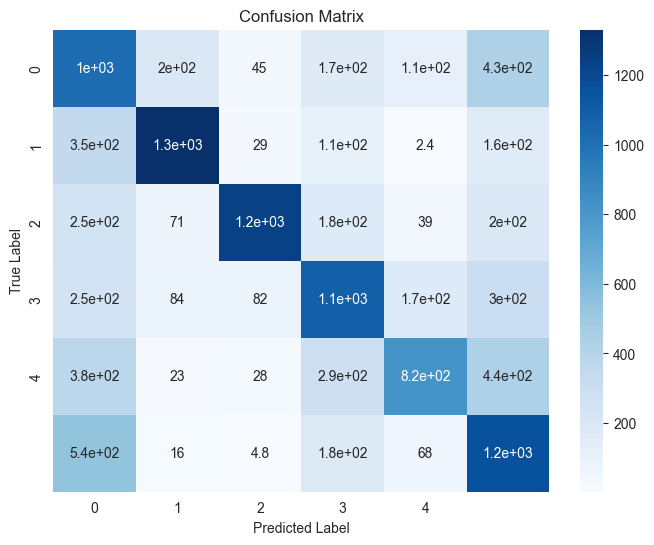

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(np.mean(CM_lst_S2, axis=0), annot=True, cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

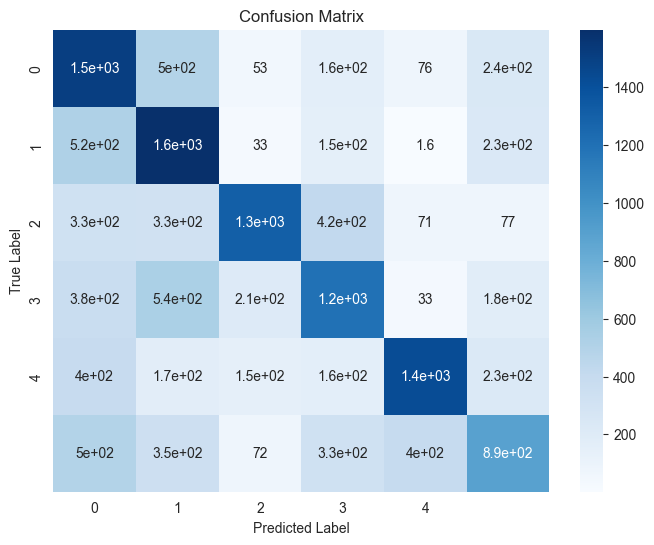

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(np.mean(CM_lst_S3, axis=0), annot=True, cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [12]:
pd.DataFrame(np.mean(CM_lst_S2, axis=0)).to_csv('./Amputee-iENG-S2-cross-val-6class.csv', index=False)
pd.DataFrame(np.mean(CM_lst_S3, axis=0)).to_csv('./Amputee-iENG-S3-cross-val-6class.csv', index=False)